# Day 23 – Linear Regression Training Model


## Goal
Understand:
- Linear Regression
- Normal Equation
- Batch Gradient Descent
- MSE Cost Function
- Learning rate effects
- Computational complexity
- Model assumptions

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

## Create a Simple Dataset

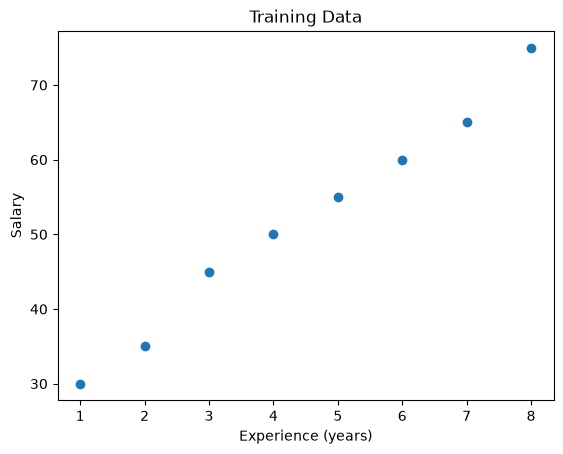

In [13]:
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8]], dtype=float)
y = np.array([30,35,45,50,55,60,65,75], dtype=float)

plt.scatter(X, y)
plt.xlabel("Experience (years)")
plt.ylabel("Salary")
plt.title("Training Data")
plt.show()

## Intuition
We try to fit a line:

**salary = intercept + slope × experience**

## Scikit-Learn Solution

In [14]:
model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 24.285714285714278
Slope: 6.130952380952383


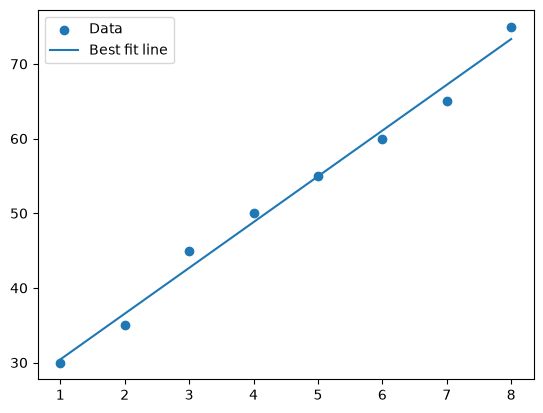

In [15]:
plt.scatter(X, y, label="Data")
plt.plot(X, model.predict(X), label="Best fit line")
plt.legend()
plt.show()

## Normal Equation
Closed-form solution:

\[
\theta = (X^T X)^{-1} X^T y
\]

This is the normal equation for linear regression.

- X is the feature matrix
- y is the target vector
- θ contains the model parameters (intercept + coefficients)
- We add a column of ones to X so the model can learn an intercept term

In matrix form, we solve for the best coefficients by minimizing the squared error:

\[
\min_\theta \|X\theta - y\|^2
\]

The expression inside the inverse, $X^T X$, is the Gram matrix. Multiplying by $X^T y$ gives the best-fit coefficients in one direct calculation.

This is a closed-form solution, which means we get the exact optimum without iterative gradient descent.


In [16]:
X_b = np.c_[np.ones((len(X), 1)), X]

# X_b adds a bias/intercept column:
# [[1, x1],
#  [1, x2],
#  ...]
# This lets the model learn: y = b0 + b1 * x

# theta_best computes the best parameters using the normal equation:
# theta = (X_b^T X_b)^(-1) X_b^T y
# It solves the least-squares problem directly in one step.

theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(theta_best)


[24.28571429  6.13095238]


## Prediction with Normal Equation

In [17]:
X_new = np.array([[9]])
X_new_b = np.c_[np.ones((1,1)), X_new]
prediction = X_new_b.dot(theta_best)

print("Predicted salary for 9 years experience:", prediction[0])

Predicted salary for 9 years experience: 79.4642857142857


## Mean Squared Error

In [18]:
y_pred = X_b.dot(theta_best)
mse = np.mean((y - y_pred)**2)
print("MSE:", mse)

MSE: 2.269345238095239


## Batch Gradient Descent from Scratch

In [19]:
eta = 0.01
n_iterations = 1000
m = len(X_b)

theta = np.random.randn(2)

cost_history = []

for iteration in range(n_iterations):
    gradients = (2/m) * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    cost = np.mean((X_b.dot(theta) - y)**2)
    cost_history.append(cost)

print(theta)

[23.88329344  6.20252813]


## Cost vs Iteration

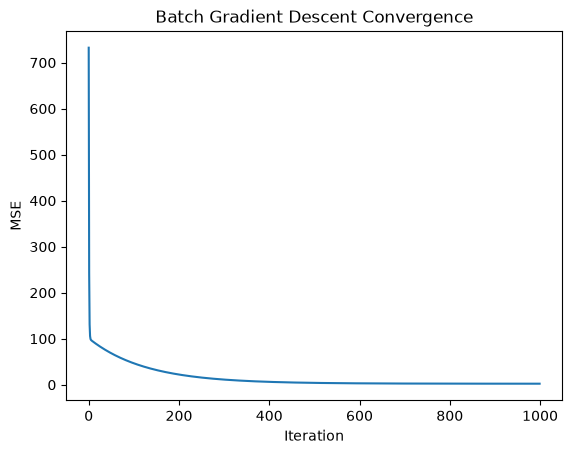

In [20]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Batch Gradient Descent Convergence")
plt.show()

## Compare Learning Rates

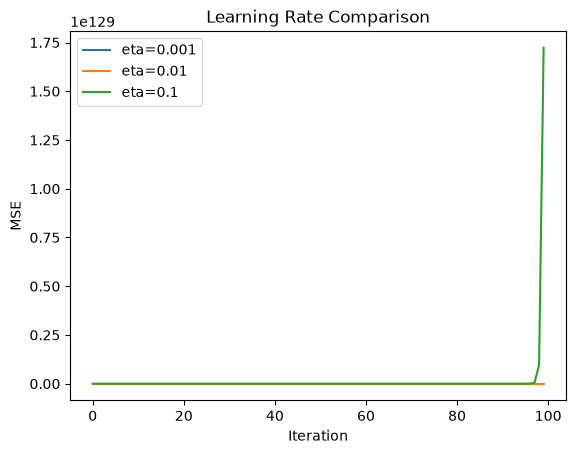

In [21]:
learning_rates = [0.001, 0.01, 0.1]

for eta in learning_rates:
    theta = np.random.randn(2)
    history = []

    for i in range(100):
        gradients = (2/m) * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        history.append(np.mean((X_b.dot(theta) - y)**2))

    plt.plot(history, label=f"eta={eta}")

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Learning Rate Comparison")
plt.show()

## Computational Complexity

| Method | Complexity | Best Use |
|---|---|---|
| Normal Equation | O(n³) | Small number of features |
| Batch Gradient Descent | O(mn) per iteration | Large datasets |
| SGD | O(n) per update | Very large datasets |
| Mini-batch GD | Between SGD and Batch GD | Practical deep learning |

## Linear Regression Assumptions

1. Linear relationship  
2. Independent observations  
3. Constant variance (homoscedasticity)  
4. Errors roughly normally distributed  
5. Low multicollinearity

## Residual Plot

A residual plot helps us check whether the model is fitting the data well.

Residuals are the differences between the actual values and the predicted values:

\[
\text{residual} = y - \hat{y}
\]

In this plot:
- x-axis = predicted values
- y-axis = residuals
- a good linear model should show residuals spread randomly around zero
- if the residuals form a curve or pattern, it suggests the model is missing some structure in the data
- if the spread is uneven, it may indicate non-constant variance or poor model assumptions

This plot is useful because a low MSE alone does not guarantee the model is appropriate. Residuals tell us whether the errors are random or systematic.


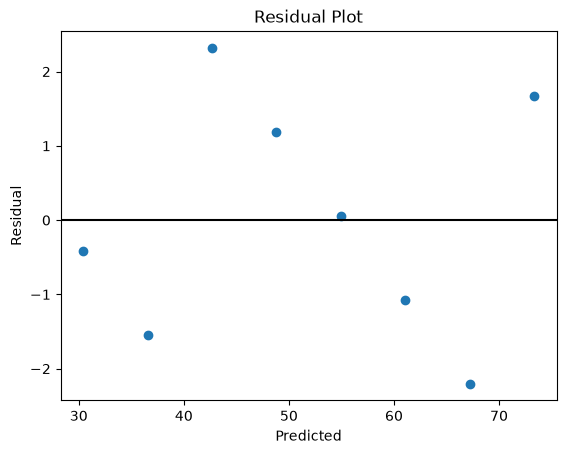

In [22]:
residuals = y - y_pred

plt.axhline(0, color='black')
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## Key Takeaways
- Normal Equation gives an exact solution.
- Gradient Descent learns parameters iteratively.
- MSE measures prediction error.
- Learning rate controls step size.
- Residual plots help check assumptions.